## Loading the Dataset 

In [47]:
from sklearn.datasets import load_iris


iris = load_iris()

# X = iris.data      # Features
# y = iris.target    # Labels

print(iris.data.shape)
print(iris.target.shape)
print("Target names: ",iris.target_names)


(150, 4)
(150,)
Target names:  ['setosa' 'versicolor' 'virginica']


## Exploring the data

In [48]:
import pandas as pd

#Creating a dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target
df["target"] = iris.target

print("\nHead:")
print(df.head())

print("\nInfo:")
print(df.info())

print("\nDescribe:")
print(df.describe())


Head:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  target  
0        0       0  
1        0       0  
2        0       0  
3        0       0  
4        0       0  

Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4  

## Visual Exploration

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species', 'target'],
      dtype='str')
Renamed columns:  Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species',
       'target'],
      dtype='str')
Pair Plot:



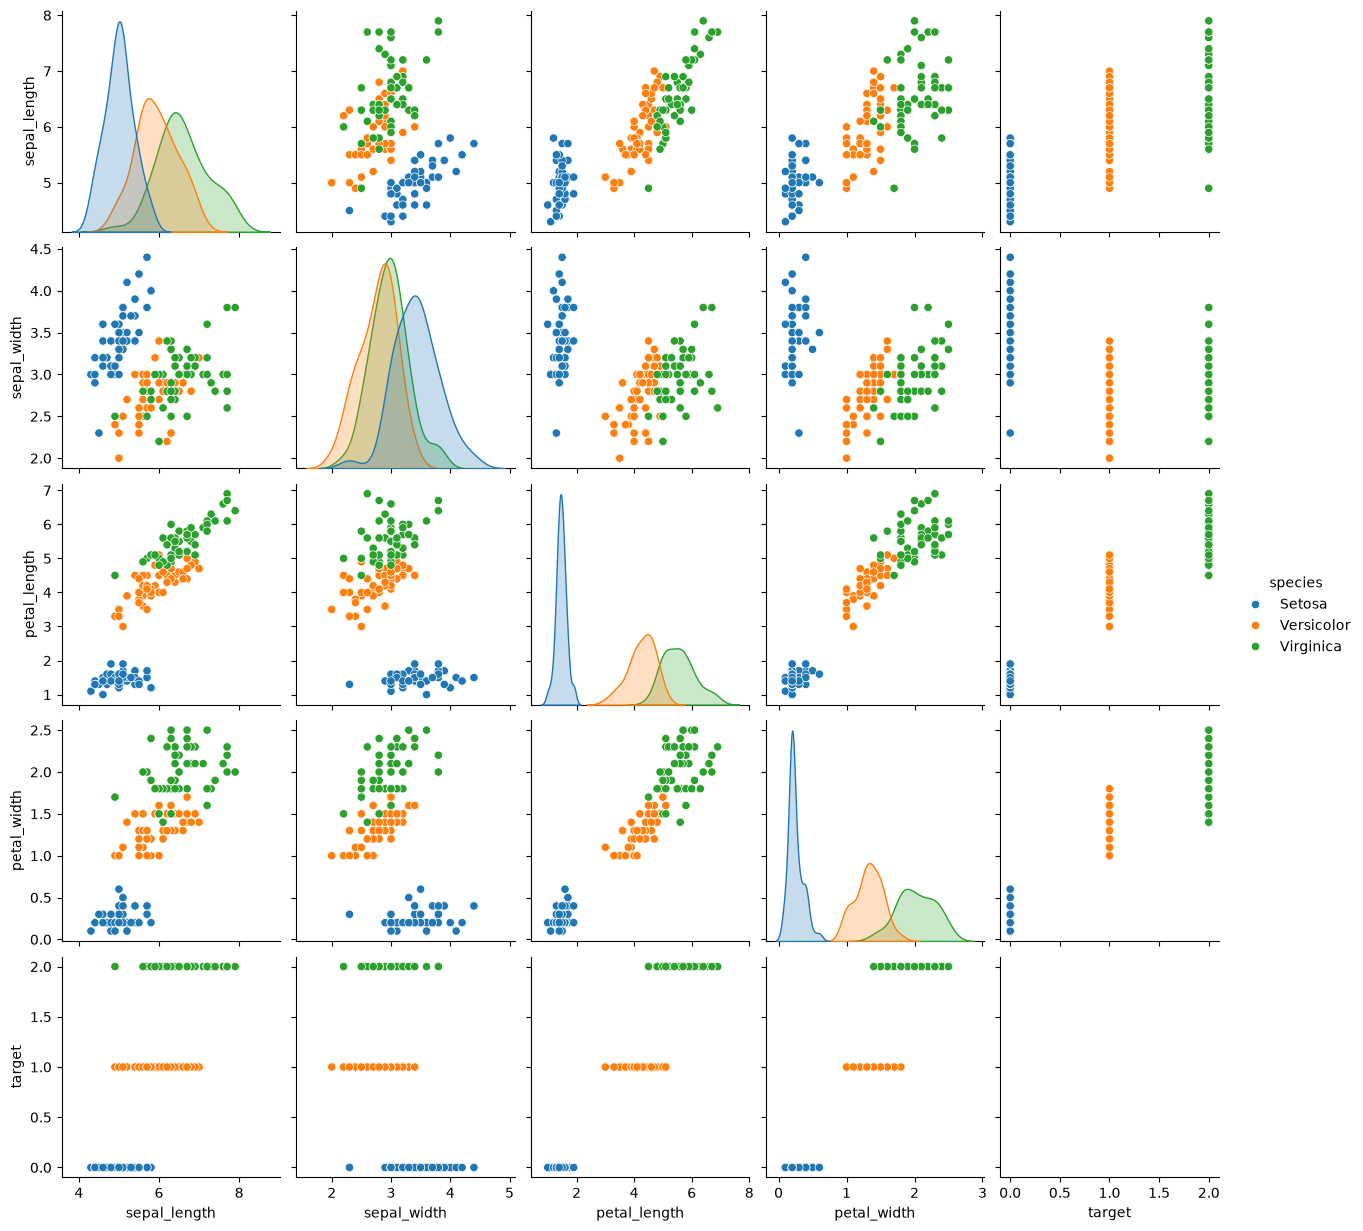

Correlation Heatmap:



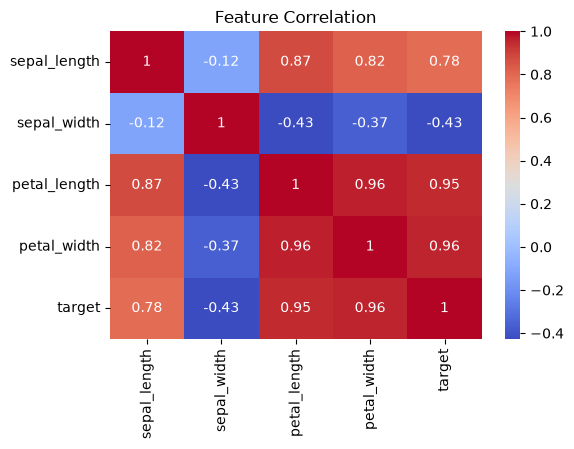

Histogram



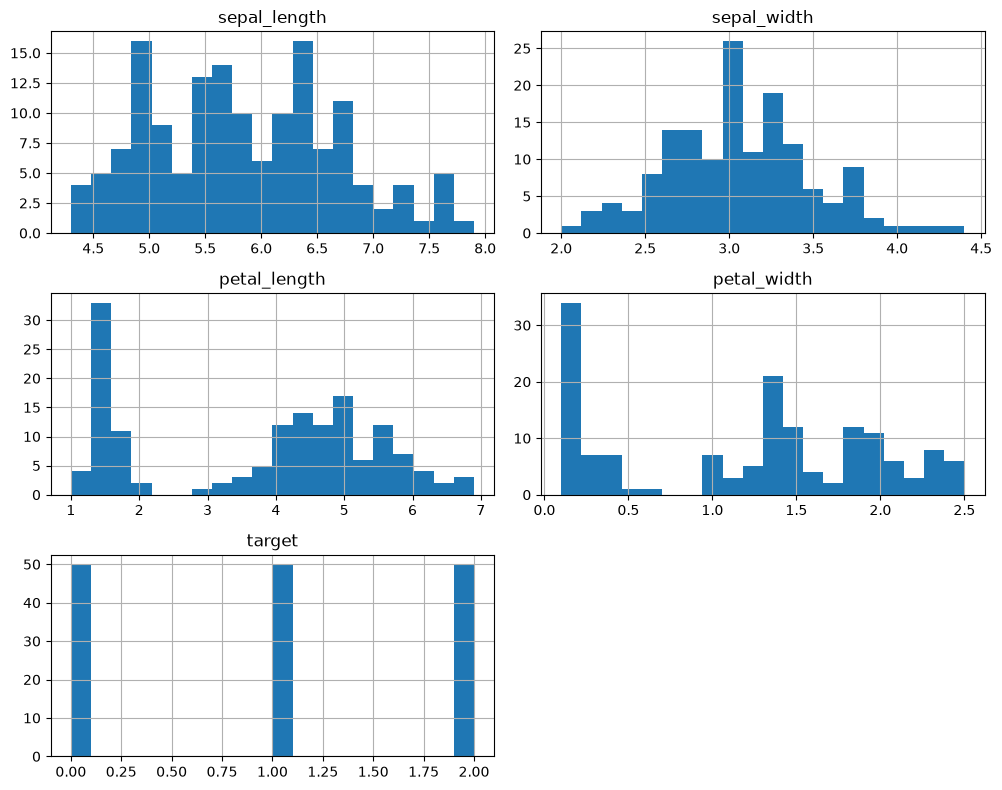

Box Plot:



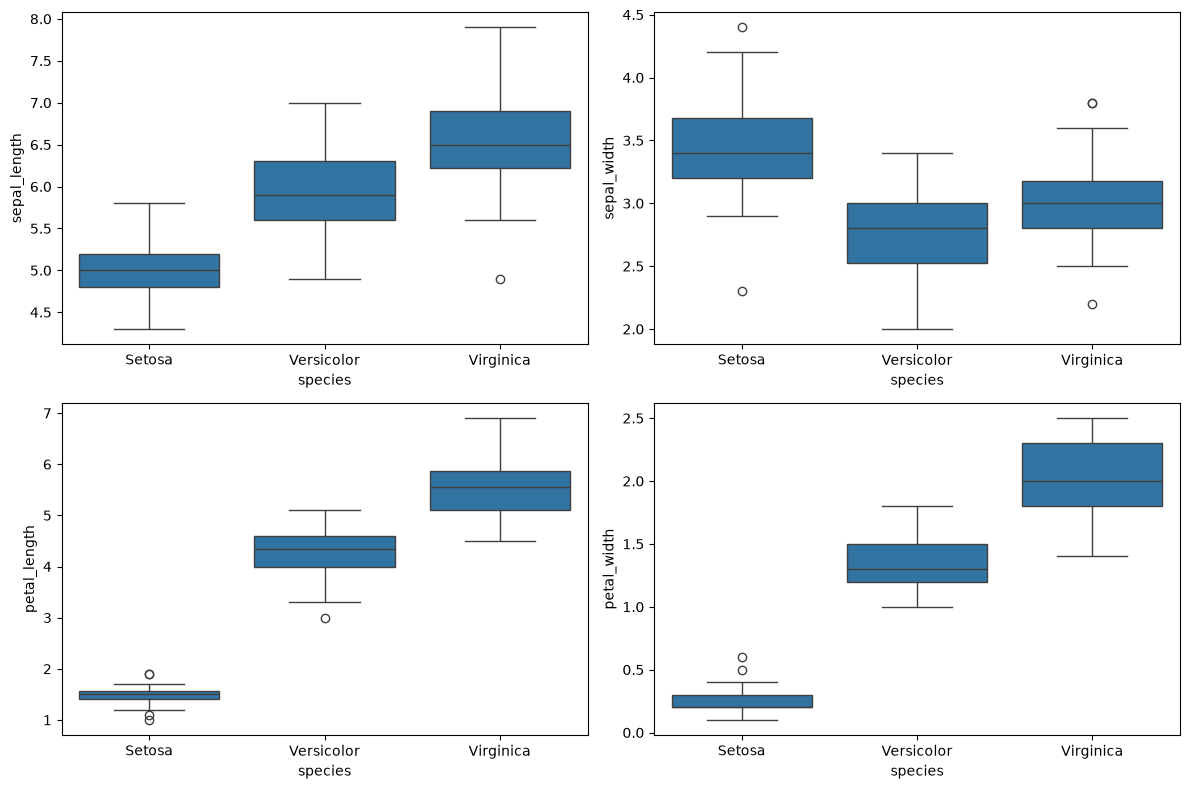

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
print(df.columns)

df.columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species",
    "target"
]

print("Renamed columns: ", df.columns)
species_names = {
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
}

df["species"] = df["specie"].map(species_names)

print("Pair Plot:\n")
sns.pairplot(df, hue="species")
plt.show()


print("Correlation Heatmap:\n")
plt.figure(figsize=(6,4))
sns.heatmap(df.drop("species", axis=1).corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

print("Histogram\n")
df.hist(figsize=(10,8), bins=20)
plt.tight_layout()
plt.show()

print("Box Plot:\n")
fig, axes = plt.subplots(2, 2, figsize=(12,8))

sns.boxplot(data=df, x="species", y="sepal_length", ax=axes[0,0])
sns.boxplot(data=df, x="species", y="sepal_width", ax=axes[0,1])
sns.boxplot(data=df, x="species", y="petal_length", ax=axes[1,0])
sns.boxplot(data=df, x="species", y="petal_width", ax=axes[1,1])

plt.tight_layout()
plt.show()


## Train-Test Split
The dataset is split into training and testing sets.
- Training set: Used to train the model.
- Testing set: Used to evaluate how well the model generalizes to unseen data.

We use an 80-20 split with a fixed random state for reproducibility.

In [54]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop("species", axis=1)   # Remove the label column
y = df["species"]                # Keep it as the target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 120
Testing samples: 30

Training class distribution:
species
Setosa        40
Virginica     40
Versicolor    40
Name: count, dtype: int64

Testing class distribution:
species
Setosa        10
Virginica     10
Versicolor    10
Name: count, dtype: int64


## Model Training - Logistic Regression

Logistic Regression is a widely used classification algorithm that predicts the probability of each class.

The model is trained using the training dataset.

In [55]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression(random_state=42)

# Train
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## Predictions

The trained model is used to predict the species of flowers in the test dataset.

In [56]:
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

print("\nActual Labels:")
print(y_test.values[:10])

First 10 Predictions:
['Setosa' 'Virginica' 'Versicolor' 'Versicolor' 'Setosa' 'Versicolor'
 'Setosa' 'Setosa' 'Virginica' 'Versicolor']

Actual Labels:
<StringArray>
[    'Setosa',  'Virginica', 'Versicolor', 'Versicolor',     'Setosa',
 'Versicolor',     'Setosa',     'Setosa',  'Virginica', 'Versicolor']
Length: 10, dtype: str


In [57]:
print(df.dtypes)
print(df.head())

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
target            int64
dtype: object
   sepal_length  sepal_width  petal_length  petal_width species  target
0           5.1          3.5           1.4          0.2  Setosa       0
1           4.9          3.0           1.4          0.2  Setosa       0
2           4.7          3.2           1.3          0.2  Setosa       0
3           4.6          3.1           1.5          0.2  Setosa       0
4           5.0          3.6           1.4          0.2  Setosa       0


## Model Evaluation - Accuracy

Accuracy measures the percentage of correctly classified samples out of the total test samples.

It is calculated as:

Accuracy = (Correct Predictions) / (Total Predictions)

In [58]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 1.0000
Accuracy: 100.00%


## Classification Report

The classification report provides:
- Precision
- Recall
- F1-score
- Support

for each iris species.

In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00        10
   Virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions made by the model for each class.

[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


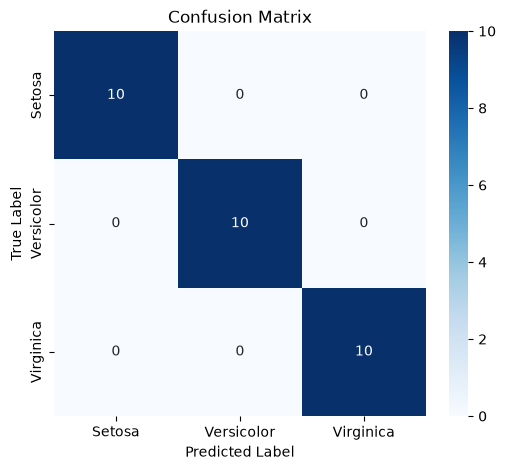

In [61]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Results

- The Logistic Regression model achieved high accuracy on the Iris dataset.
- Most flowers were classified correctly.
- The confusion matrix shows very few or no misclassifications.
- This indicates that the four flower measurements are highly effective for distinguishing the three iris species.